# 1. Setup & Data Loading

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr, spearmanr

In [51]:
sns.set_theme(style="whitegrid")

In [52]:
data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 2. Data Quality Check

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [54]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 2.1 Missing Values & Duplicates

In [55]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [56]:
data.duplicated().sum()

np.int64(0)

There are no null values or duplicates in this dataset.

### 2.2 Zero-Variance & Irrelevant Features

In [57]:
zero_variance_cols = [col for col in data.columns if data[col].nunique() <= 1]
print(zero_variance_cols)

['EmployeeCount', 'Over18', 'StandardHours']


In [58]:
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = data.drop(columns=drop_cols)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

'EmployeeCount', 'Over18', 'StandardHours' all contain the same value across all entries and can be removed.

### 2.3 Data Type Adjustments

In [60]:
df['Attrition'] = df['Attrition'].map({'Yes': True, 'No': False})
df['OverTime'] = df['OverTime'].map({'Yes': True, 'No': False})

In [61]:
objcols = ['BusinessTravel', 'EducationField', 'Gender', 'Department', 'JobRole', 'MaritalStatus']
df[objcols] = df[objcols].astype('category')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   bool    
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   category
 8   EnvironmentSatisfaction   1470 non-null   int64   
 9   Gender                    1470 non-null   category
 10  HourlyRate                1470 non-null   int64   
 11  JobInvolvement            1470 non-null   int64   
 12  JobLevel                  1470 non-null   int64   
 13  JobRole                   1470 non-null   catego

Change object type to category type/bool type for less data usage.

# Exploratory Data Analysis

*Ordinal variables are treated as numerical*

Ordinal variable ranks: 1 'Low' 2 'Medium' 3 'High' 4 'Very High'

Education: 1 'Below College' 2 'College' 3 'Bachelor' 4 'Master' 5 'Doctor'

WorkLifeBalance: 1 'Bad' 2 'Good' 3 'Better' 4 'Best'

PerformanceRating: 1 'Low' 2 'Good' 3 'Excellent' 4 'Outstanding'

### 3.1 Target Variable Distribution (Attrition)

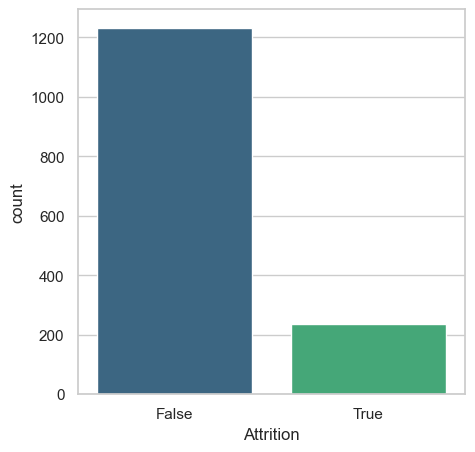

In [63]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.show()

In [64]:
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
False    83.877551
True     16.122449
Name: proportion, dtype: float64


The dataset is approximately 84% entries with `attrition` = False and 16% entries with `attrition` = True. The dataset exhibits class imbalance, machine learning models may become biased toward predicting the majority class.

### 3.2 Employee Demographics

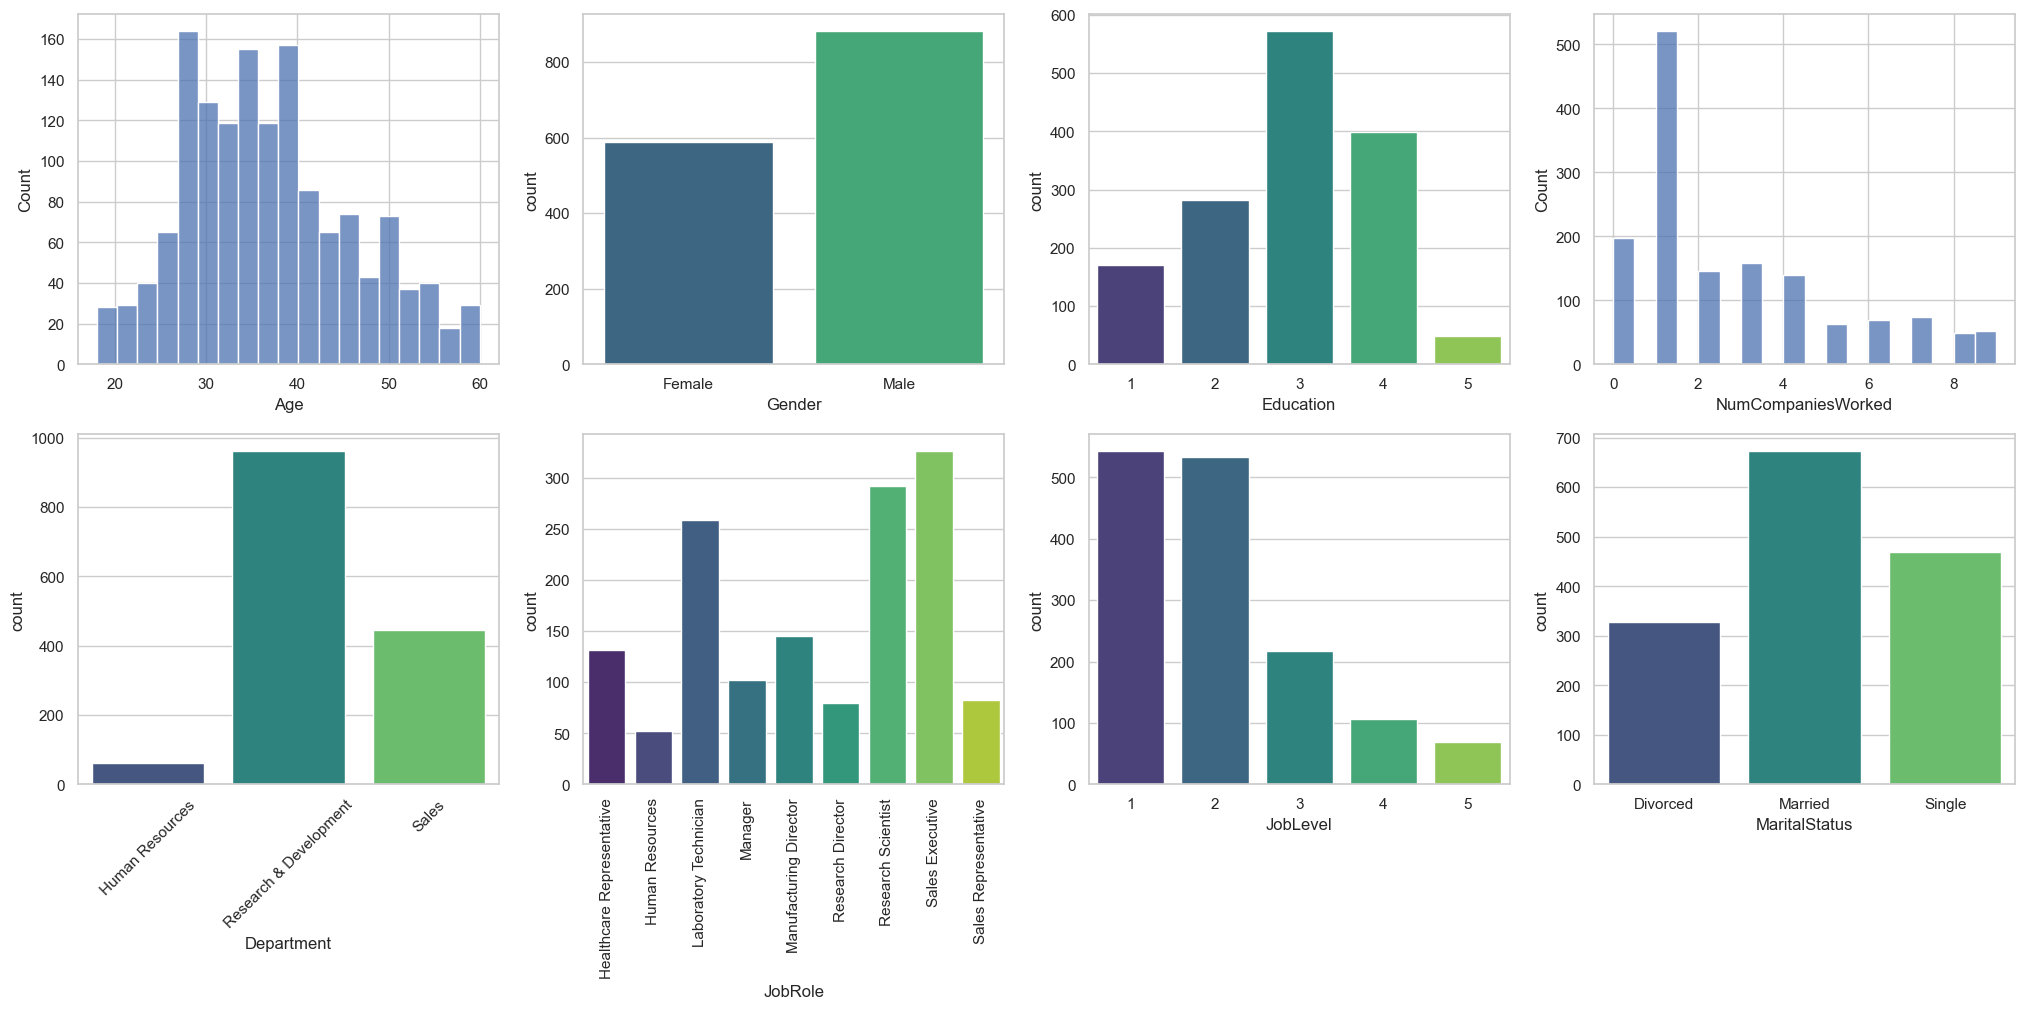

In [65]:
plt.figure(figsize=(25, 10))
plt.subplot(2,4,1)
sns.histplot(df['Age'])
plt.subplot(2,4,2)
sns.countplot(data=df, x='Gender', palette='viridis')
plt.subplot(2,4,3)
sns.countplot(data=df, x='Education', palette='viridis')
plt.subplot(2,4,4)
sns.histplot(df['NumCompaniesWorked'])
plt.subplot(2,4,5)
sns.countplot(data=df, x='Department', palette='viridis')
plt.xticks(rotation=45)
plt.subplot(2,4,6)
sns.countplot(data=df, x='JobRole', palette='viridis')
plt.xticks(rotation=90)
plt.subplot(2,4,7)
sns.countplot(data=df, x='JobLevel', palette='viridis')
plt.subplot(2,4,8)
sns.countplot(data=df, x='MaritalStatus', palette='viridis')
plt.show()

1. The workforce is relatively mature, with a median age of ~36.
2. Gender distribution is slightly skewed toward males (60/40).
3. The most common education level among employees is a bachelor's degree. 
4. The distribution of NumCompaniesWorked is right-skewed. Most employees have worked in 1 to 2 companies previously.
5. The most common department among employees is R&D.
6. The most common job roles are Sales Executive, Research Scientist, and Laboratory Technician.
7. Most employees are at job level 1 or 2.
8. The most common marital status among employees is Married.

### 3.3 Satisfaction & Work Conditions

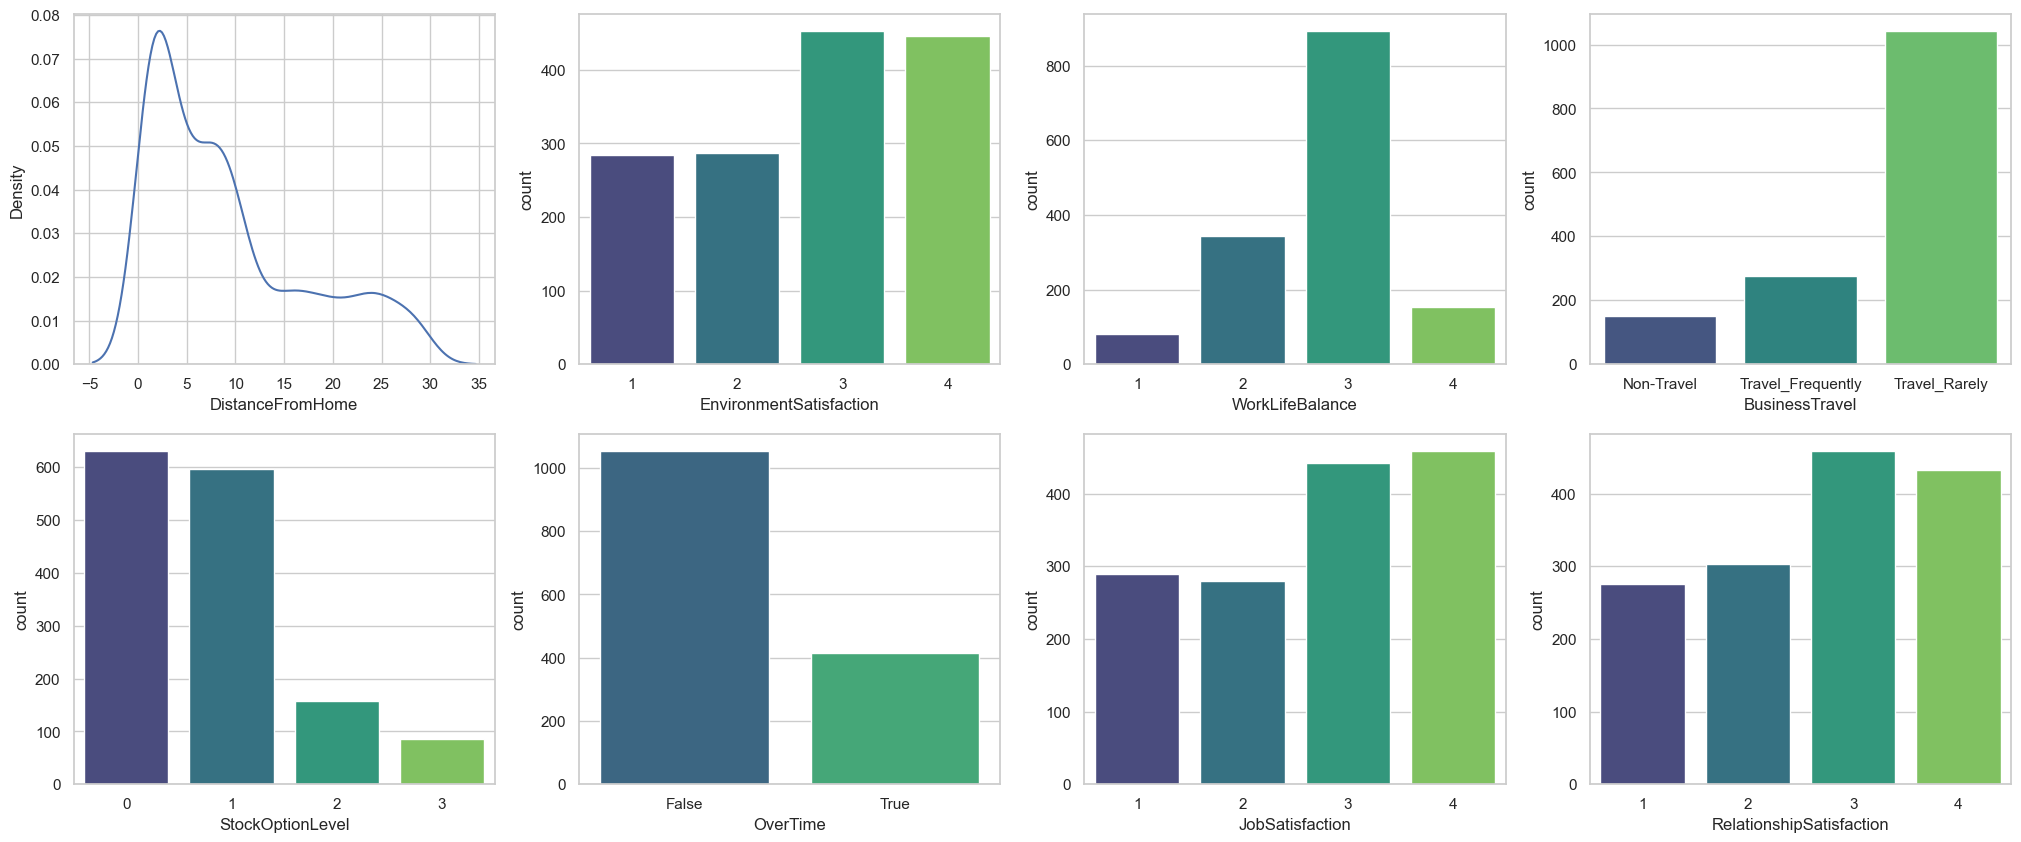

In [66]:
plt.figure(figsize=(25, 10))
plt.subplot(2,4,1)
sns.kdeplot(df['DistanceFromHome'])
plt.subplot(2,4,2)
sns.countplot(data=df, x='EnvironmentSatisfaction', palette='viridis')
plt.subplot(2,4,3)
sns.countplot(data=df, x='WorkLifeBalance', palette='viridis')
plt.subplot(2,4,4)
sns.countplot(data=df, x='BusinessTravel', palette='viridis')
plt.subplot(2,4,5)
sns.countplot(data=df, x='StockOptionLevel', palette='viridis')
plt.subplot(2,4,6)
sns.countplot(data=df, x='OverTime', palette='viridis')
plt.subplot(2,4,7)
sns.countplot(data=df, x='JobSatisfaction', palette='viridis')
plt.subplot(2,4,8)
sns.countplot(data=df, x='RelationshipSatisfaction', palette='viridis')
plt.show()

1. The distribution of Distance from home is right-skewed. Most employees live close to the company (<5 distance units).
2. Environment satisfaction is generally "High" and "Very High".
3. Work-life balance is generally "Better".
4. Most employees travel rarely in regards to frequency of business travel.
5. Most employees have a stock option level of 0 to 1.
6. About 28% of employees work overtime.
7. Job satisfaction is generally "High" and "Very High".
8. Relationship satisfaction is generally "High" and "Very High".

### 3.4 Work Performance

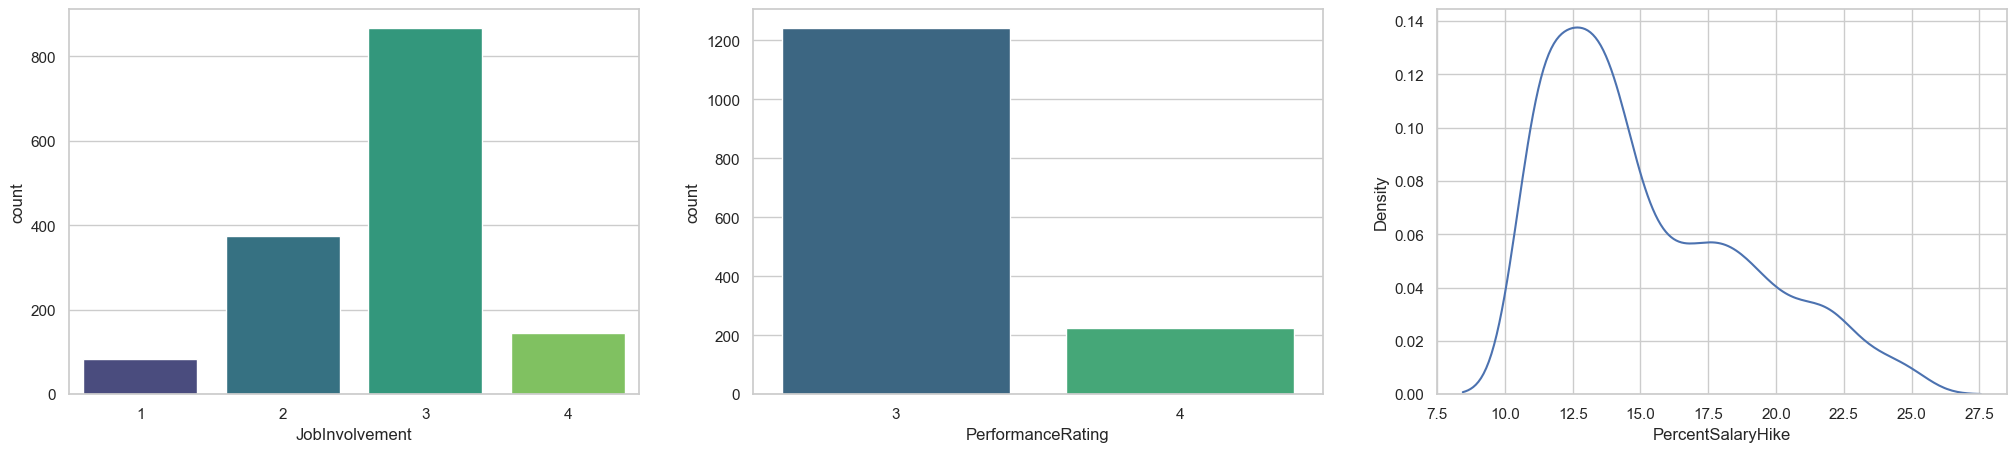

In [67]:
plt.figure(figsize=(25, 5))
plt.subplot(1,3,1)
sns.countplot(data=df, x='JobInvolvement', palette='viridis')
plt.subplot(1,3,2)
sns.countplot(data=df, x='PerformanceRating', palette='viridis')
plt.subplot(1,3,3)
sns.kdeplot(df['PercentSalaryHike'])
plt.show()

1. Most common level of job involvement is "High".
2. Most common level of performance rating is "Excellent". *Performance Rating is mostly 3 and have no 1-2 level ratings (low variance)*
3. The distribution of Percent Salary Hike is right skewed, with most employees earning a lower annual salary hike.

### 3.5 Compensation

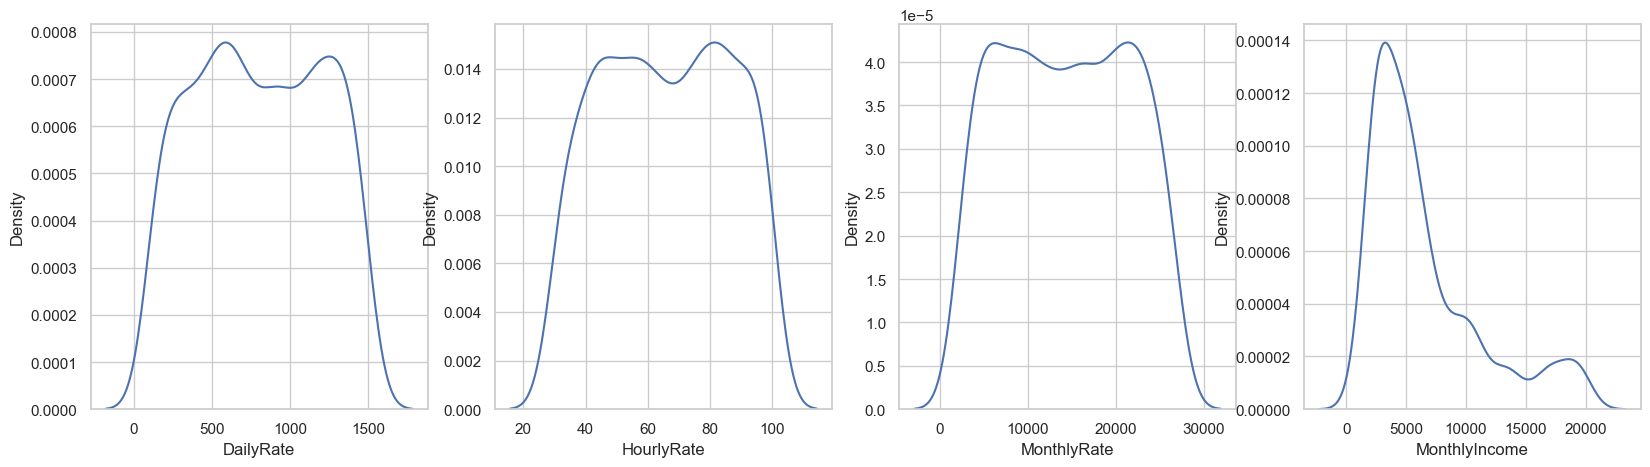

In [68]:
plt.figure(figsize=(20, 5))
plt.subplot(1,4,1)
sns.kdeplot(df['DailyRate'])
plt.subplot(1,4,2)
sns.kdeplot(df['HourlyRate'])
plt.subplot(1,4,3)
sns.kdeplot(df['MonthlyRate'])
plt.subplot(1,4,4)
sns.kdeplot(df['MonthlyIncome'])
plt.show()

1. The distribution of Daily Rate appears uniform.
2. The distribution of Hourly Rate appears uniform.
3. The distribution of Monthly Rate appears uniform.
4. The distribution of Monthly Income is right-skewed, with most employees earning less.

In [69]:
df_calc = df.copy()
df_calc['Hourly_to_Daily'] = df_calc['DailyRate'] / df_calc['HourlyRate']
df_calc['Daily_to_Monthly'] = df_calc['MonthlyRate'] / df_calc['DailyRate']

unique_hourly_ratios = df_calc['Hourly_to_Daily'].nunique()
unique_monthly_ratios = df_calc['Daily_to_Monthly'].nunique()

print(f"Number of unique Hourly-to-Daily ratios: {unique_hourly_ratios}")
print(f"Number of unique Daily-to-Monthly ratios: {unique_monthly_ratios}")

print(f"Std Dev of Hourly-to-Daily: {df_calc['Hourly_to_Daily'].std():.2f}")

Number of unique Hourly-to-Daily ratios: 1438
Number of unique Daily-to-Monthly ratios: 1470
Std Dev of Hourly-to-Daily: 8.79


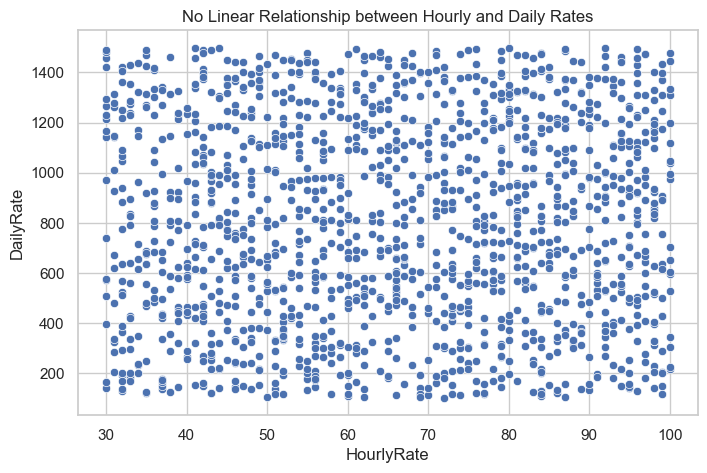

In [70]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_calc, x='HourlyRate', y='DailyRate')
plt.title("No Linear Relationship between Hourly and Daily Rates")
plt.show()

The rate-related variables (`HourlyRate`, `DailyRate`, `MonthlyRate`) are not mathematically linked. This suggests these values represent independent administrative metrics rather than a unified payroll calculation. `Monthly Income` is the most reliable representation of employee earnings in terms of interpretation.

### 3.6 Tenure & Career Progression

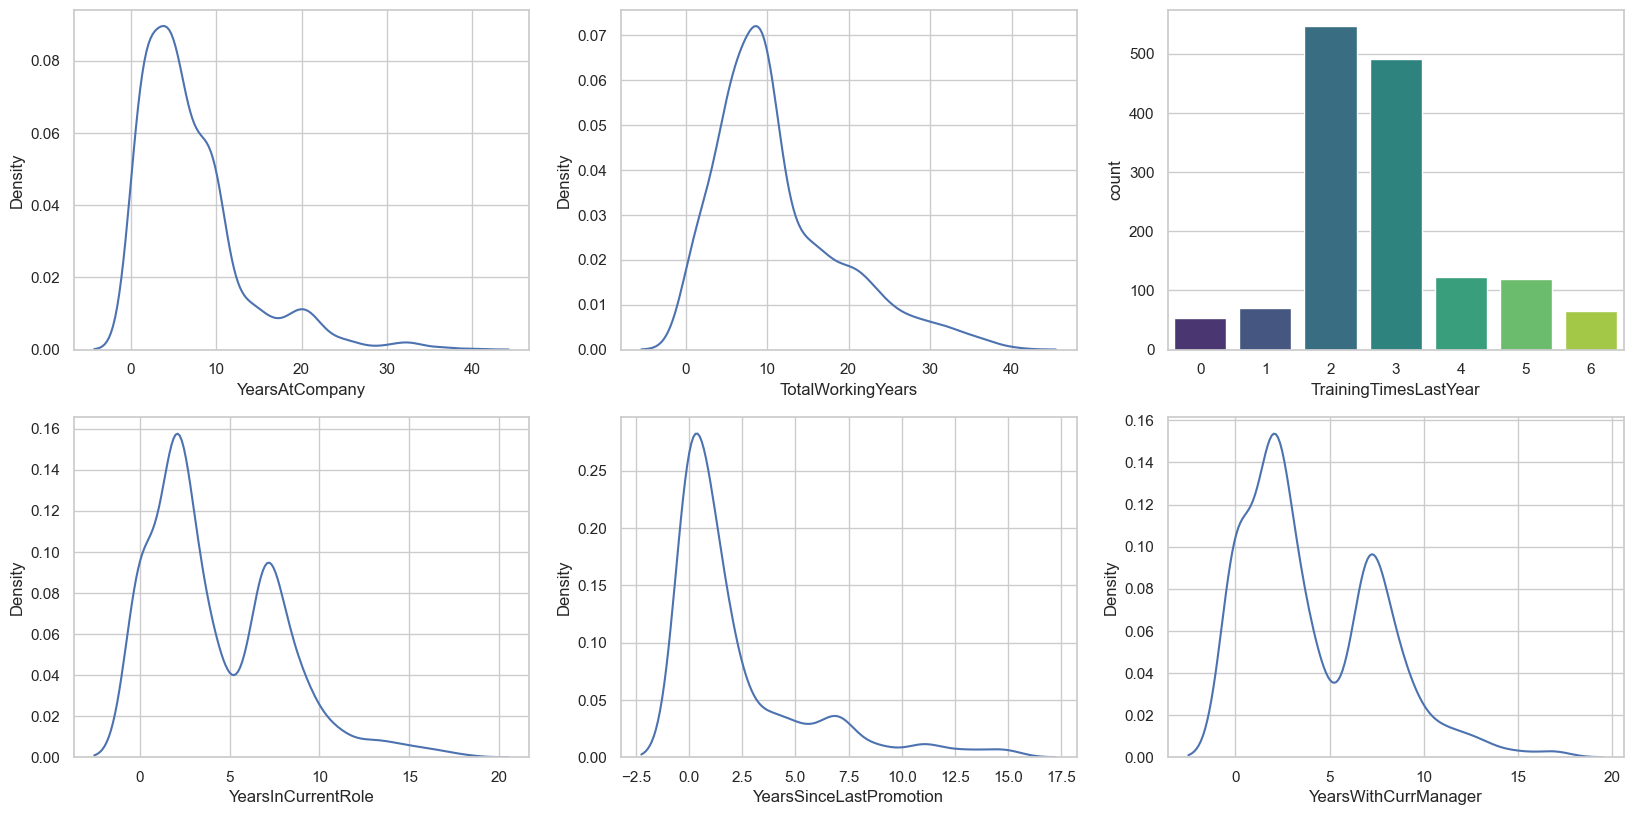

In [71]:
plt.figure(figsize=(20, 15))
plt.subplot(3,3,1)
sns.kdeplot(df['YearsAtCompany'])
plt.subplot(3,3,2)
sns.kdeplot(df['TotalWorkingYears'])
plt.subplot(3,3,3)
sns.countplot(data=df, x='TrainingTimesLastYear', palette='viridis')
plt.subplot(3,3,4)
sns.kdeplot(df['YearsInCurrentRole'])
plt.subplot(3,3,5)
sns.kdeplot(df['YearsSinceLastPromotion'])
plt.subplot(3,3,6)
sns.kdeplot(df['YearsWithCurrManager'])
plt.show()

1. The distribution for Years at company is right-skewed. Most employees have worked for less than 10 years in the company.
2. The distribution for Total working years is right-skewed. Most employees have worked for less than 10 years in total.
3. The most common training times last year is 2 and 3 times.
4. The distribution for Total working years is slightly right-skewed with two peaks. Most employees have spent less than 5 years in their current role, with another peak at slightly over 5 years.
5. The distribution for Years since last promotion is right-skewed. Most employees have worked for less than 10 years in total.
6. The distribution for Years with current manager is similar to the distribution for Years in current role, likely because a change in role often comes with a change in manager.

In [72]:
corr, p_value = pearsonr(df['YearsInCurrentRole'], df['YearsWithCurrManager'])
print(f"Correlation: {corr:.2f}, P-value: {p_value:}")
corr, p_value = spearmanr(df['YearsInCurrentRole'], df['YearsWithCurrManager'])
print(f"Spearman Correlation: {corr:.2f}")

Correlation: 0.71, P-value: 7.276486188183238e-230
Spearman Correlation: 0.72


Tested Years with current manager with Years in current role. The p-value is less than 0.05 and the correlation scores are around 0.71, indicating high correlation. One of the variables should be dropped to preserve interpretability and for Logistic Regression purposes (avoid multicollinearity due to coefficient issues).

# 4. Attrition Analysis


### 4.1 Correlation with Numerical Variables

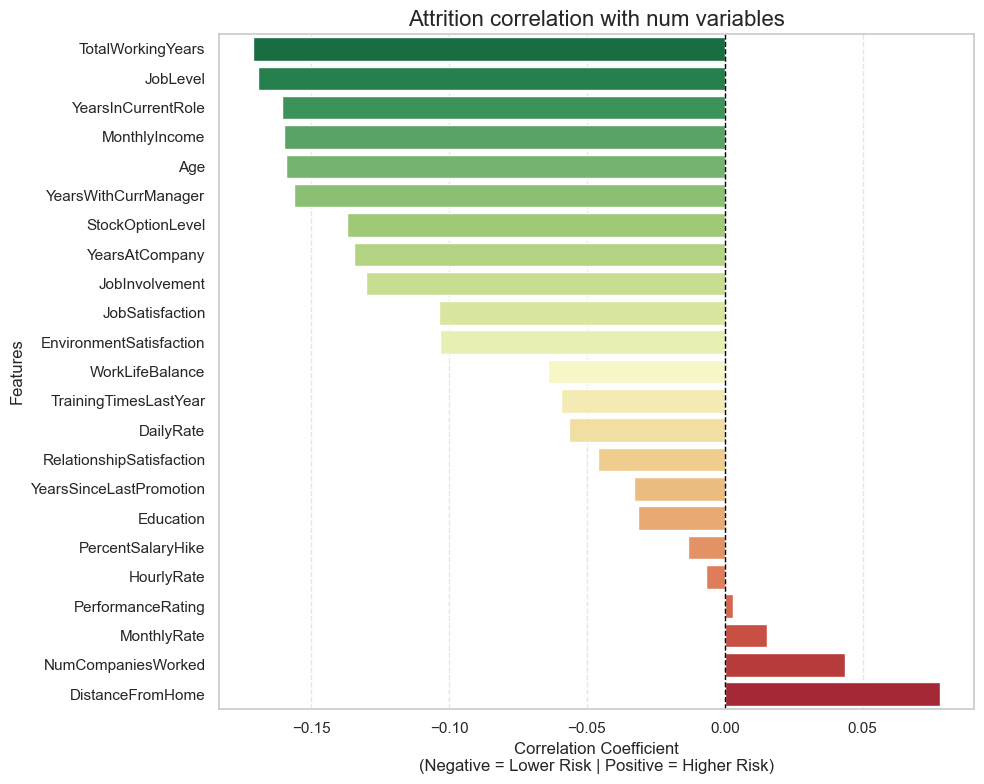

In [73]:
df['Attrition_Binary'] = df['Attrition'].map({True: 1, False: 0})
numeric_correlations = df.select_dtypes(include=['number']).corr()['Attrition_Binary'].sort_values()
numeric_correlations = numeric_correlations.drop('Attrition_Binary')
plt.figure(figsize=(10, 8))
sns.barplot(x=numeric_correlations.values, y=numeric_correlations.index, palette='RdYlGn_r')
plt.title('Attrition correlation with num variables', fontsize=16)
plt.xlabel('Correlation Coefficient\n(Negative = Lower Risk | Positive = Higher Risk)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Numerical variables highly correlated with Attrition and are more actionable from an HR perspective are `TotalWorkingYears`, `JobLevel`, `YearsinCurrentRole`, `MonthlyIncome`, `StockOptionLevel`, `JobInvolvement`, and `Distancefromhome`. 

### 4.2 Correlation with Categorical & Boolean Variables

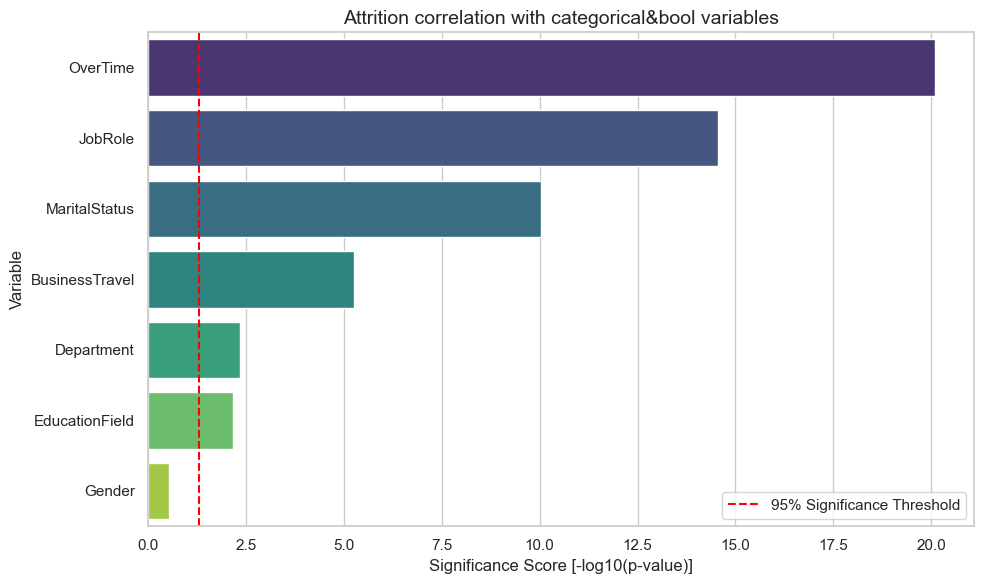

In [74]:
catbool_cols = df.select_dtypes(include=['category', 'bool']).columns.tolist()
catbool_cols = [col for col in catbool_cols if col != 'Attrition']

results = []
for col in catbool_cols:
    table = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, ex = chi2_contingency(table)
    results.append({'Variable': col, 'P_Value': p})
res_df = pd.DataFrame(results)
res_df['Score'] = -np.log10(res_df['P_Value'])
res_df = res_df.sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Variable', data=res_df, palette='viridis')
plt.axvline(x=1.3, color='red', linestyle='--', label='95% Significance Threshold')

plt.title('Attrition correlation with categorical&bool variables', fontsize=14)
plt.xlabel('Significance Score [-log10(p-value)]', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Categorical/Boolean variables highly correlated with Attrition and are more actionable from an HR perspective are `OverTime` and `JobRole`. 

### 4.3 Key Variable Deep Dives

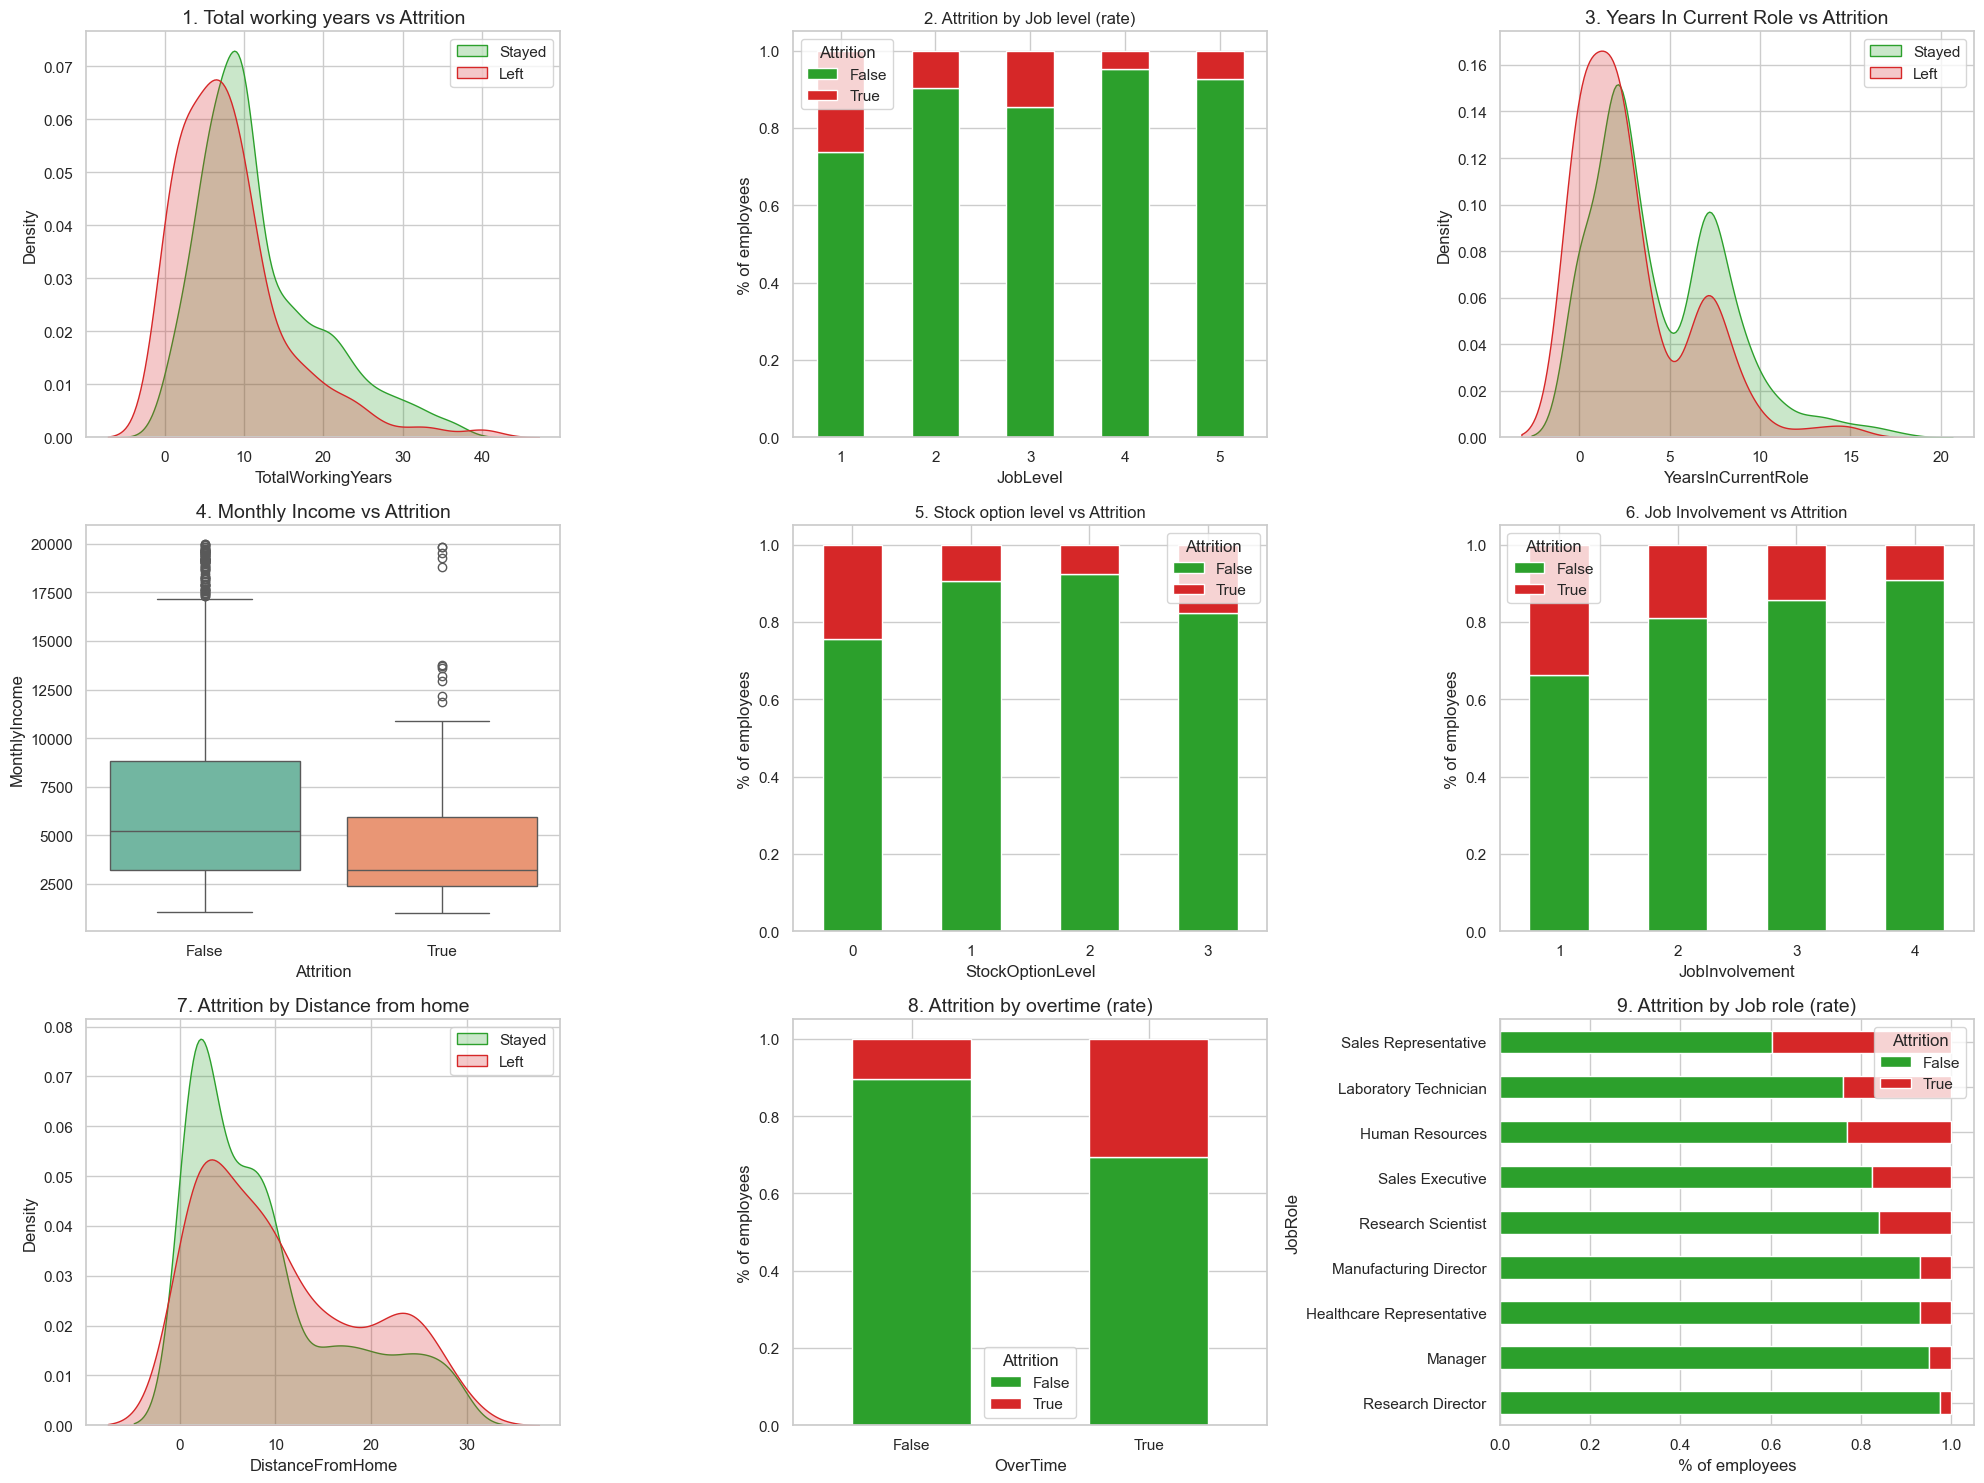

In [75]:
plt.figure(figsize=(20, 15))

plt.subplot(3,3,1)
sns.kdeplot(data=df[df['Attrition']==False], x='TotalWorkingYears', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='TotalWorkingYears', label='Left', fill=True, color='#d62728')
plt.title('1. Total working years vs Attrition', fontsize=14)
plt.legend()

plt.subplot(3,3,2)
jl_tab = pd.crosstab(df['JobLevel'], df['Attrition'], normalize='index')
jl_tab.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'], rot=0)
plt.title('2. Attrition by Job level (rate)')
plt.ylabel('% of employees')

plt.subplot(3,3,3)
sns.kdeplot(data=df[df['Attrition']==False], x='YearsInCurrentRole', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='YearsInCurrentRole', label='Left', fill=True, color='#d62728')
plt.title('3. Years In Current Role vs Attrition', fontsize=14)
plt.legend()

plt.subplot(3,3,4)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('4. Monthly Income vs Attrition', fontsize=14)

plt.subplot(3,3,5)
so_tab = pd.crosstab(df['StockOptionLevel'], df['Attrition'], normalize='index')
so_tab.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'], rot=0)
plt.title('5. Stock option level vs Attrition')
plt.ylabel('% of employees')

plt.subplot(3,3,6)
ji_tab = pd.crosstab(df['JobInvolvement'], df['Attrition'], normalize='index')
ji_tab.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'], rot=0)
plt.title('6. Job Involvement vs Attrition')
plt.ylabel('% of employees')

plt.subplot(3,3,7)
sns.kdeplot(data=df[df['Attrition']==False], x='DistanceFromHome', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='DistanceFromHome', label='Left', fill=True, color='#d62728')
plt.title('7. Attrition by Distance from home', fontsize=14)
plt.legend()

plt.subplot(3,3,8)
ot_tab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
ot_tab.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'], rot=0)
plt.title('8. Attrition by overtime (rate)', fontsize=14)
plt.ylabel('% of employees')

plt.subplot(3,3,9)
role_tab = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')
role_tab.sort_values(by=True).plot(kind='barh', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'])
plt.title('9. Attrition by Job role (rate)', fontsize=14)
plt.xlabel('% of employees')

plt.tight_layout()
plt.show()

1. The **Total working years** distribution of employees who are leaving the company is more left-skewed than employees who are staying. Employees who are leaving are more likely to have worked longer.
2. **Job Level** 1 and 3 have the highest percentage of employees who are leaving.
3. Both **Years In Current Role**  distributions have two peaks. At less than 5 years in the current role, employees are more likely to leave than at more than 5 years in the current role.
4. Employees who leave have a lower **Monthly income** range and average than employees who stay.
5. The lowest **Stock option level** have the highest percentage of employees who are leaving.
6. The lowest **Job involvement** level has the highest percentage of employees who are leaving.
7. The **Distance from home** distribution of employees who are leaving the company is less left-skewed than employees who are staying. Employees who are leaving are more likely to have larger distance from home.
8. The group of employees who work **Overtime** have a higher percentage of employees who are leaving.
9. Sales representatives have the highest percentage of employees who are leaving among **Job roles**.

# 5. Feature Engineering

### 5.1 Engineered Features & Explanation

In [76]:
df["PromotionStagnation"] = (df["YearsSinceLastPromotion"] /(df["YearsAtCompany"] + 1))

In [77]:
df["IncomePerYearExp"] = (df["MonthlyIncome"] /(df["TotalWorkingYears"] + 1))

In [78]:
df['CompanyTenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

In [79]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary,PromotionStagnation,IncomePerYearExp,CompanyTenureRatio
0,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,1,6,4,0,5,1,0.000000,665.888889,0.666667
1,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3,3,10,7,1,7,0,0.090909,466.363636,0.909091
2,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,3,0,0,0,0,1,0.000000,261.250000,0.000000
3,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,8,7,3,0,0,0.333333,323.222222,0.888889
4,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,3,2,2,2,2,0,0.666667,495.428571,0.285714


1. `PromotionStagnation`: Measures career velocity. A higher value (closer to 1.0) identifies employees who have spent a long time at the company without a promotion. 
2. `IncomePerYearExp`: Measures earning efficiency. A higher value identifies employees whose salary is high relative to their total years of experience (high market demand/mobility), while low values may indicate under-compensated, experienced employees.
3. `CompanyTenureRatio`: Measures organizational loyalty. A higher value (closer to 1.0) identifies employees who have spent their entire career at the company, while a low value indicates an employee who has a lot of outside experience.

### 5.2 Engineered Features vs Attrition

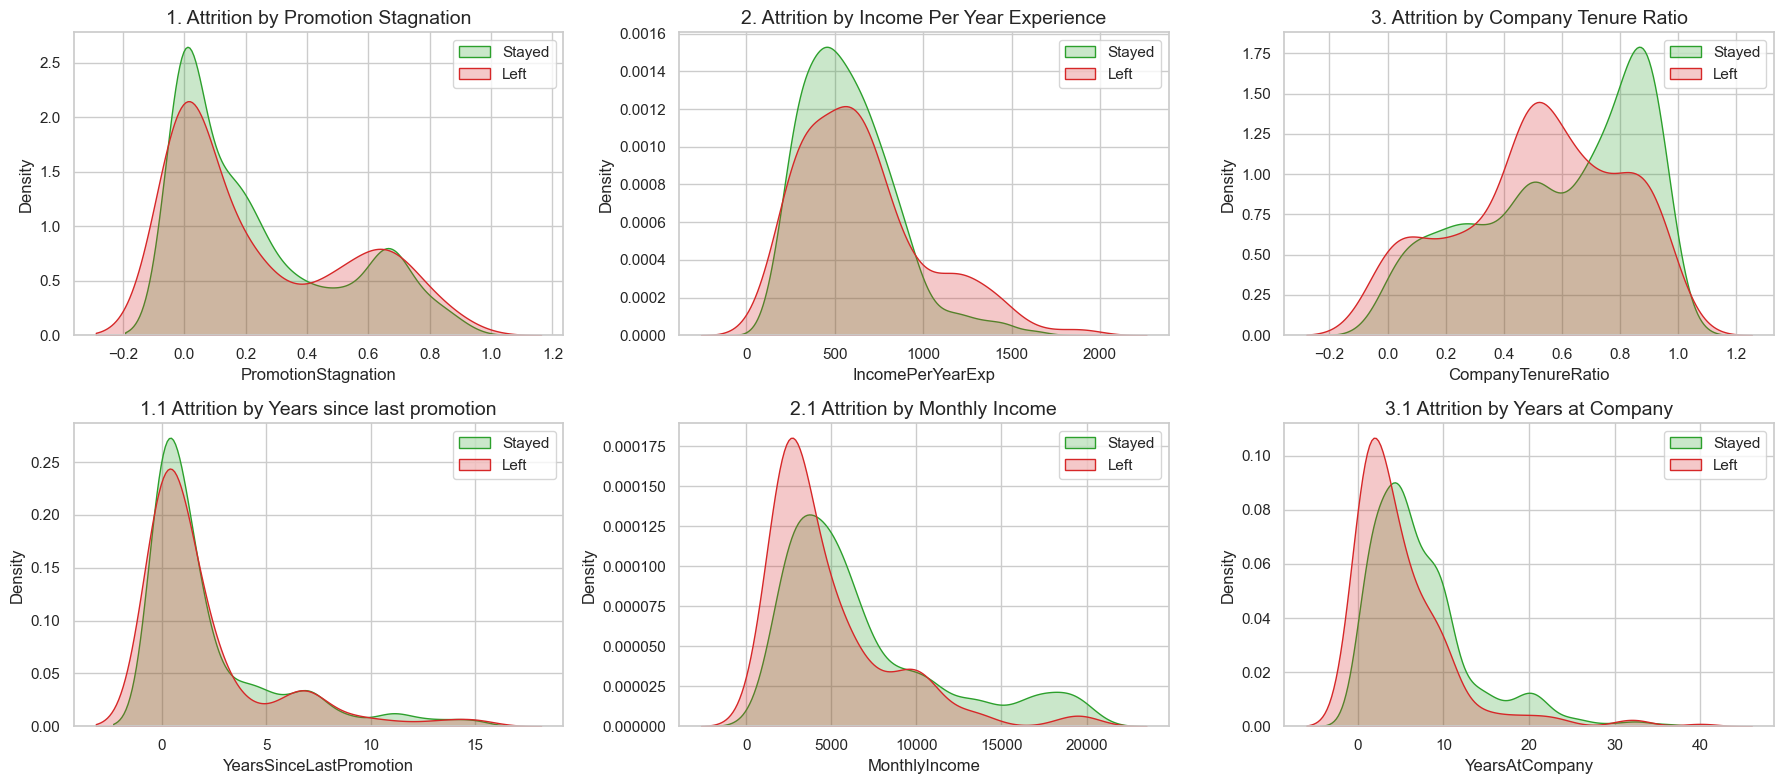

In [80]:
plt.figure(figsize=(18, 8))

plt.subplot(2,3,1)
sns.kdeplot(data=df[df['Attrition']==False], x='PromotionStagnation', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='PromotionStagnation', label='Left', fill=True, color='#d62728')
plt.title('1. Attrition by Promotion Stagnation', fontsize=14)
plt.legend()

plt.subplot(2,3,2)
sns.kdeplot(data=df[df['Attrition']==False], x='IncomePerYearExp', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='IncomePerYearExp', label='Left', fill=True, color='#d62728')
plt.title('2. Attrition by Income Per Year Experience', fontsize=14)
plt.legend()

plt.subplot(2,3,3)
sns.kdeplot(data=df[df['Attrition']==False], x='CompanyTenureRatio', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='CompanyTenureRatio', label='Left', fill=True, color='#d62728')
plt.title('3. Attrition by Company Tenure Ratio', fontsize=14)
plt.legend()

plt.subplot(2,3,4)
sns.kdeplot(data=df[df['Attrition']==False], x='YearsSinceLastPromotion', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='YearsSinceLastPromotion', label='Left', fill=True, color='#d62728')
plt.title('1.1 Attrition by Years since last promotion', fontsize=14)
plt.legend()

plt.subplot(2,3,5)
sns.kdeplot(data=df[df['Attrition']==False], x='MonthlyIncome', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='MonthlyIncome', label='Left', fill=True, color='#d62728')
plt.title('2.1 Attrition by Monthly Income', fontsize=14)
plt.legend()

plt.subplot(2,3,6)
sns.kdeplot(data=df[df['Attrition']==False], x='YearsAtCompany', label='Stayed', fill=True, color='#2ca02c')
sns.kdeplot(data=df[df['Attrition']==True], x='YearsAtCompany', label='Left', fill=True, color='#d62728')
plt.title('3.1 Attrition by Years at Company', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

1. `Promotion Stagnation` v.s. `Years since last promotion`:
- Normalize data (effect more observable): employees who spend a higher percentage of their career without a promotion are significantly more likely to leave. 

2. `IncomePerYearExperience` v.s. `MonthlyIncome`
- Employees with lower pay-to-experience efficiency are less likely to leave.
- Reveals different information compared to Monthly Income (chart 2.1).

3. `CompanyTenureRatio` v.s. `Years at Company`
- Normalize data: employees who spend a higher percentage of their career at this company are less likely to leave.
- Years at Company (chart 3.1) only shows how newer employees leave more. Company Tenure Ratio (chart 3) Reveals different information.

# 6. Multicollinearity Analysis

### 6.1 Correlation Heatmap

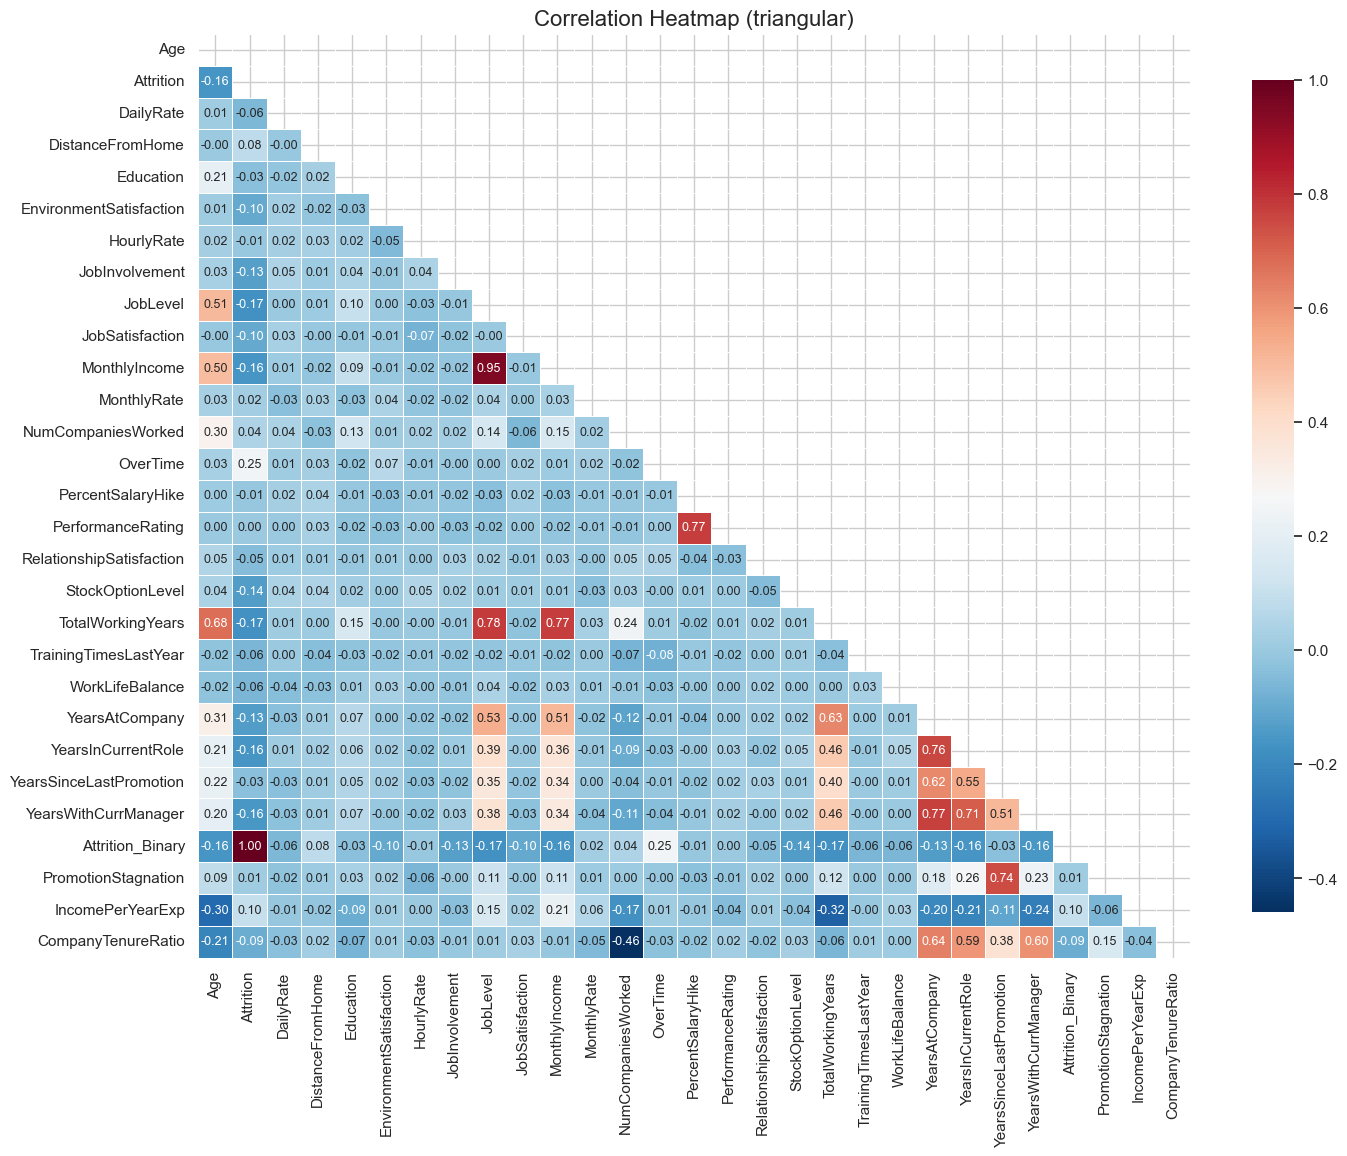

In [81]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', linewidths=.5, cbar_kws={"shrink": .9},annot_kws={"size": 9})
plt.title('Correlation Heatmap (triangular)', fontsize=16)
plt.show()

Check for possible multicollinearity problems (use 0.7 as cutoff):

1. `Total Working Years` v.s. `Job Level` v.s. `Monthly Income` (about 0.77)
- **verdict** = drop `Job Level`, drop `Total working years`, keep `Monthly Income`.
- `Monthly Income` reflects `Job level` good enough, and its numeric data type is more flexible.
- Information of `Total working years` is partially preserved in `Company Tenure Ratio`.

2. `Percent Salary Hike` v.s. `Performance Rating` (0.77)
- **verdict** = drop `Performance rating`, keep `Percent Salary Hike`.
- `Performance rating` is an important aspect of determining whether employee attrition is important for a company. However, `Percent Salary Hike` has more information than `Performance rating` (the latter has mostly same values/low variance), so in this case I elected to use `Percent Salary Hike` as the main indicator of Job performance.

3. `Promotion Stagnation` v.s. `Years Since Last Promotion` (about 0.74)
- **verdict** = drop `Years since Last promotion`, keep `Promotion stagnation`
- Explained previously in engineered feature EDA.

4. `Years in Current Role` v.s. `Years At Company` v.s. `Years Since Last Promotion` (about 0.51 ~ 0.76)
- **verdict** = keep `Years in Current Role`, drop `Years At Company` (`Years since Last promotion` already dropped from 5.)
- `Years in Current Role` is more correlated to Attrition than `Years At Company`.
- Information of `Years at Company` is partially preserved in `Company Tenure Ratio`.

5. `Years in Current Role` v.s. `Years with Current Manager` (about 0.71)
- **verdict** = keep `Years in Current Role`, drop `Years with Current Manager`.
- Explained previously in EDA.


### 6.2 VIF Analysis

In [82]:
numeric_df = df.select_dtypes(include=['number']).dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) 
                   for i in range(len(numeric_df.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                     feature         VIF
13         PerformanceRating  137.257479
7                   JobLevel   49.996697
12         PercentSalaryHike   43.503206
9              MonthlyIncome   40.375411
16         TotalWorkingYears   35.781764
0                        Age   33.412834
26        CompanyTenureRatio   27.337689
19            YearsAtCompany   21.773965
18           WorkLifeBalance   15.490325
6             JobInvolvement   15.225680
25          IncomePerYearExp   14.741483
5                 HourlyRate   11.337394
3                  Education    9.409440
21   YearsSinceLastPromotion    7.454359
14  RelationshipSatisfaction    7.296885
4    EnvironmentSatisfaction    7.180754
8            JobSatisfaction    7.090137
22      YearsWithCurrManager    6.968289
20        YearsInCurrentRole    6.851103
24       PromotionStagnation    5.881147
17     TrainingTimesLastYear    5.616192
10               MonthlyRate    5.080677
1                  DailyRate    4.986037
11        NumCom

VIF directly tests for multicollinearity in datasets.

### 6.3 Final Feature Removal Decisions

In [83]:
df_rm = df.drop(columns=['JobLevel', 'Attrition_Binary', 'PerformanceRating', 'YearsSinceLastPromotion','YearsAtCompany','YearsWithCurrManager','TotalWorkingYears'], axis=1)
df_rm = df_rm.drop(columns=['HourlyRate','DailyRate','MonthlyRate'], axis=1)

- `JobLevel`: collinear with `MonthlyIncome`
- `PerformanceRating`: collinear with `PercentSalaryHike`
- `YearsWithCurrManager`: collinear with `YearsInCurrentRole`
- `YearsSinceLastPromotion`: collinearity issues, partially preserved with `PromotionStagnation`
- `YearsAtCompany` & `TotalWorkingYears`: collinearity issues, partially preserved with `CompanyTenureRatio`
Removed due to difficult interpretation: `HourlyRate`, `DailyRate`, `MonthlyRate`

# 7. Data Preparation

### 7.1 Final Feature Set

In [84]:
df_rm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   bool    
 2   BusinessTravel            1470 non-null   category
 3   Department                1470 non-null   category
 4   DistanceFromHome          1470 non-null   int64   
 5   Education                 1470 non-null   int64   
 6   EducationField            1470 non-null   category
 7   EnvironmentSatisfaction   1470 non-null   int64   
 8   Gender                    1470 non-null   category
 9   JobInvolvement            1470 non-null   int64   
 10  JobRole                   1470 non-null   category
 11  JobSatisfaction           1470 non-null   int64   
 12  MaritalStatus             1470 non-null   category
 13  MonthlyIncome             1470 non-null   int64 

### 7.2 Encoding

In [85]:
df_final = pd.get_dummies(df_rm, drop_first=True)

The dropped dummy categories are `BusinessTravel_No`, `Department_HR`, `Gender_Female`, and `MaritalStatus_Divorced`.

In [86]:
df_final.head()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,True,1,2,2,3,4,5993,8,True,...,False,False,False,False,False,False,True,False,False,True
1,49,False,8,1,3,2,2,5130,1,False,...,False,False,False,False,False,True,False,False,True,False
2,37,True,2,2,4,2,3,2090,6,True,...,False,True,False,False,False,False,False,False,False,True
3,33,False,3,4,4,3,3,2909,1,True,...,False,False,False,False,False,True,False,False,True,False
4,27,False,2,1,1,3,2,3468,9,False,...,False,True,False,False,False,False,False,False,True,False


In [87]:
bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

In [88]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   DistanceFromHome                   1470 non-null   int64  
 3   Education                          1470 non-null   int64  
 4   EnvironmentSatisfaction            1470 non-null   int64  
 5   JobInvolvement                     1470 non-null   int64  
 6   JobSatisfaction                    1470 non-null   int64  
 7   MonthlyIncome                      1470 non-null   int64  
 8   NumCompaniesWorked                 1470 non-null   int64  
 9   OverTime                           1470 non-null   int64  
 10  PercentSalaryHike                  1470 non-null   int64  
 11  RelationshipSatisfaction           1470 non-null   int64

### 7.3 Final VIF & Correlation check

In [89]:
numeric_df_drop = df_rm.select_dtypes(include=['number']).dropna()
vif_data_drop = pd.DataFrame()
vif_data_drop["feature"] = numeric_df_drop.columns
vif_data_drop["VIF"] = [variance_inflation_factor(numeric_df_drop.values, i) 
                   for i in range(len(numeric_df_drop.columns))]
print(vif_data_drop.sort_values(by="VIF", ascending=False))

                     feature        VIF
0                        Age  25.993859
8          PercentSalaryHike  15.706409
12           WorkLifeBalance  14.456715
4             JobInvolvement  14.112897
16        CompanyTenureRatio  10.568942
2                  Education   9.269725
9   RelationshipSatisfaction   7.168410
15          IncomePerYearExp   7.139478
3    EnvironmentSatisfaction   6.926513
5            JobSatisfaction   6.833257
6              MonthlyIncome   5.778930
13        YearsInCurrentRole   5.632321
11     TrainingTimesLastYear   5.502515
7         NumCompaniesWorked   2.969358
1           DistanceFromHome   2.284050
14       PromotionStagnation   1.900570
10          StockOptionLevel   1.885121


VIF scores dropped to a relatively acceptable range.

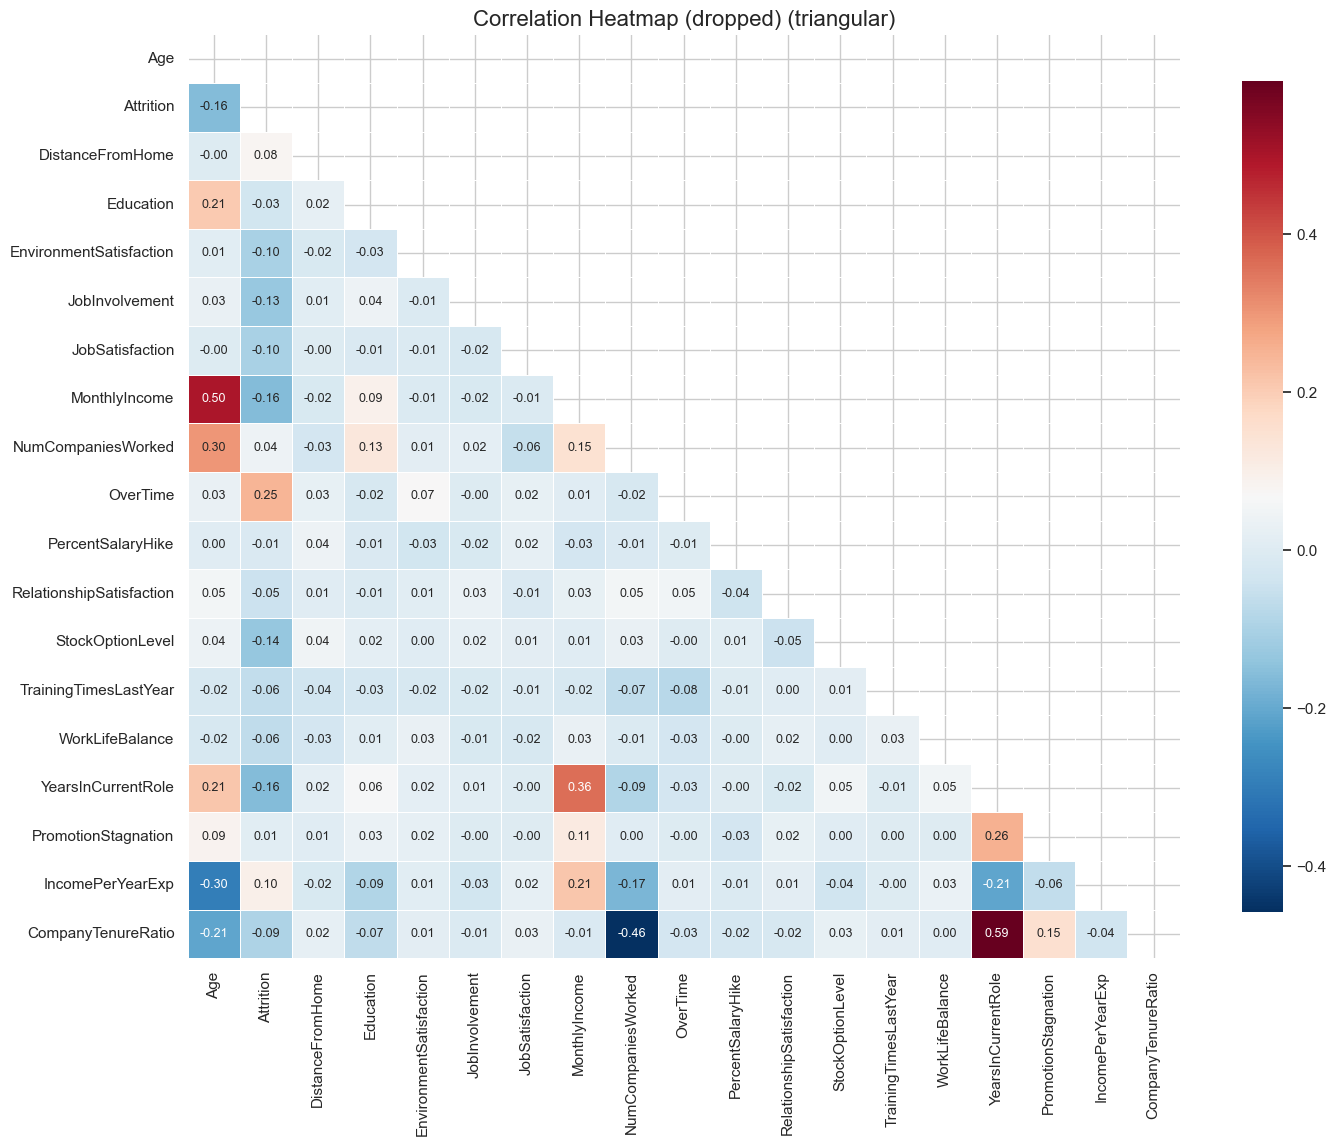

In [90]:
corr = df_rm.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', linewidths=.5, cbar_kws={"shrink": .9},annot_kws={"size": 9})
plt.title('Correlation Heatmap (dropped) (triangular)', fontsize=16)
plt.show()

After dropping variables, no pairs of variables have significant collinearity (>0.7) with each other. This is required for explaining coefficients and feature importance. 

# 8. CSV download

In [92]:
df_final.to_csv('final_HR-Employee-Attrition.csv',index=False)

# 9. Notes for ML Team

1. There is class imbalance in this dataset.
2. The main feature measuring job performance is `Percent Salary Hike`.
3. Scaling is required before running Logistic Regression/distance-based models.